# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_csv('Iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


<Axes: xlabel='Species', ylabel='count'>

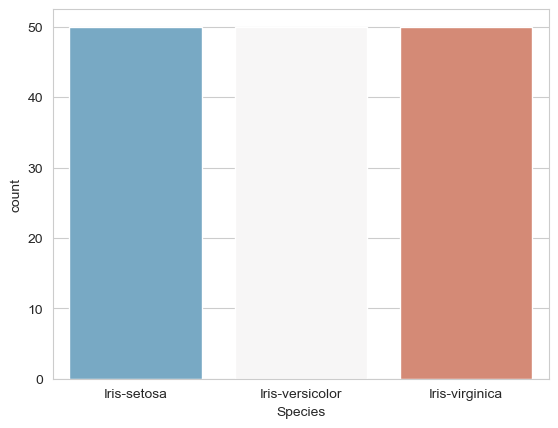

In [6]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, hue='Species', palette='RdBu_r')

<Axes: xlabel='Species', ylabel='count'>

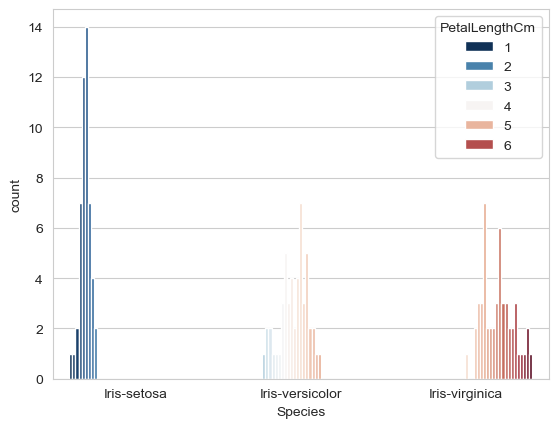

In [7]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='Species',hue='PetalLengthCm',data=train,palette='RdBu_r')

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

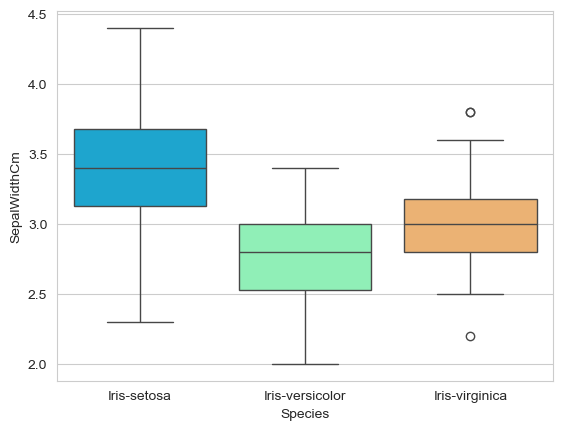

In [13]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.boxplot(x='Species', y='SepalWidthCm', data=train, palette='rainbow', hue='Species')

Text(0.5, 1.0, 'Rata-rata Panjang Kelopak Bunga berdasarkan Spesies')

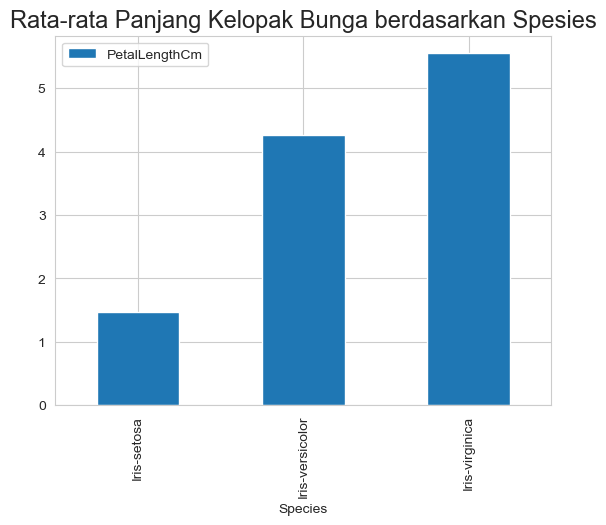

In [14]:
f_sple=train.groupby('Species')['PetalLengthCm'].mean()
f_sple = pd.DataFrame(f_sple)
f_sple
f_sple.plot.bar(y='PetalLengthCm')
plt.title("Rata-rata Panjang Kelopak Bunga berdasarkan Spesies",fontsize=17)

<Axes: xlabel='PetalLengthCm', ylabel='Count'>

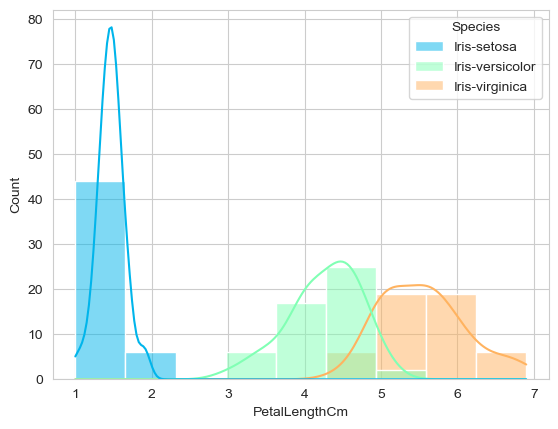

In [ ]:
# Distribusi panjang kelopak berdasarkan Species
sns.set_style('whitegrid')
sns.histplot(data= train, x='PetalLengthCm', hue= 'Species', kde = True, palette='rainbow')

<Axes: xlabel='Panjang Sepal in cm', ylabel='Count'>

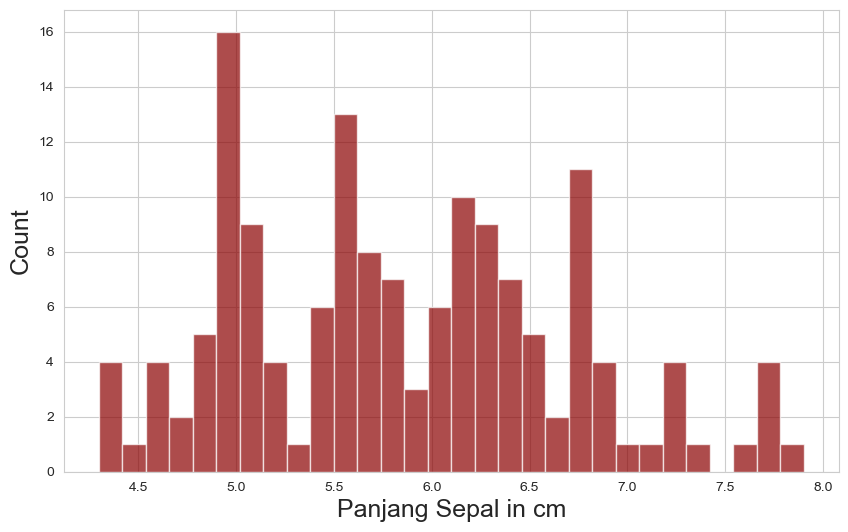

In [16]:
# Cek distribusi dari umur
plt.figure(figsize=(10,6))
plt.xlabel("Panjang Sepal in cm",fontsize=18)
plt.ylabel("Count",fontsize=18)
#plt.title("Histogram usia penumpang",fontsize=22)
train['SepalLengthCm'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

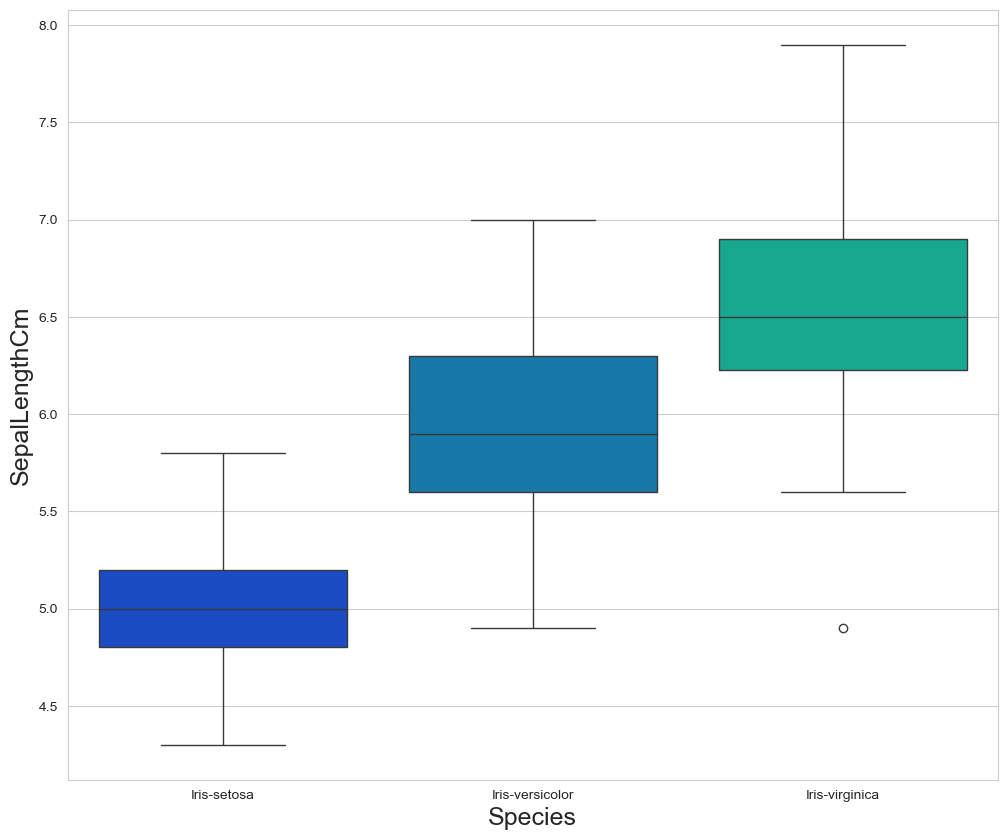

In [18]:
# Distribusi panjang sepal di setiap spesies
plt.figure(figsize=(12, 10))
plt.xlabel("Species",fontsize=18)
plt.ylabel("SepalLengthCm",fontsize=18)
sns.boxplot(x='Species',y='SepalLengthCm',data=train,palette='winter',hue='Species')

Text(0.5, 0, 'Species')

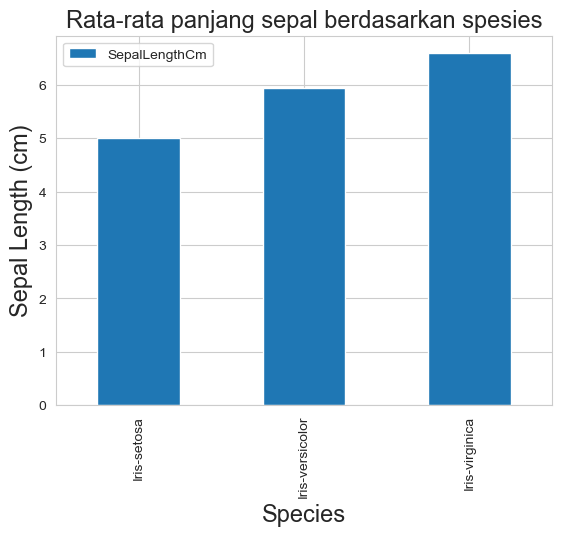

In [19]:
f_spse =train.groupby('Species')['SepalLengthCm'].mean()
f_spse = pd.DataFrame(f_spse)
f_spse.plot.bar(y='SepalLengthCm')
plt.title("Rata-rata panjang sepal berdasarkan spesies",fontsize=17)
plt.ylabel("Sepal Length (cm)", fontsize=17)
plt.xlabel("Species", fontsize=17)

### Fitur Engineering

In [20]:
a=list(f_spse['SepalLengthCm'])

def impute_sepallength(cols):
    SepalLengthCm = cols[0]
    Species = cols[1]

    if pd.isnull(SepalLengthCm):

        if Species == 'Iris-setosa':
            return a[0]

        elif Species == 'Iris-versicolor':
            return a[1]

        else:
            return a[2]

    else:
        return SepalLengthCm

In [22]:
train['SepalLengthCm'] = train[['SepalLengthCm', 'Species']].apply(impute_sepallength, axis=1)

C:\Users\user\AppData\Local\Temp\ipykernel_28816\3898713600.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SepalLengthCm = cols[0]
C:\Users\user\AppData\Local\Temp\ipykernel_28816\3898713600.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Species = cols[1]


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

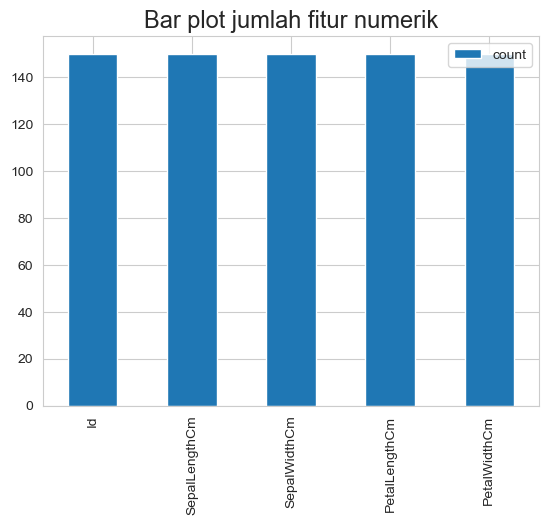

In [23]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [24]:
# drop cabin karena memiliki banyak null value (>50%)
train.drop('Id',axis=1,inplace=True)
train.dropna(inplace=True)
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [26]:
# Drop semua kolom yang tidak penting
train.drop(['Id'],axis=1,inplace=True, errors='ignore')
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Species'] = le.fit_transform(train['Species'])
#train['Embarked'] = le.fit_transform(train['Embarked'])
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Training

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Species',axis=1),
                                                    train['Species'], test_size=0.30,
                                                    random_state=42)

In [29]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (105, 4)
Test shape: (45, 4)


# **KNN**

In [30]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
y_pred = clf1.predict(X_test)

### Evaluation

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [33]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors

In [36]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [37]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [38]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [44]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])

# Prediksi apakah penumpang ini selamat atau tidak
prediction = grid_search.best_estimator_.predict(new_data)
nama_species = le.inverse_transform(prediction)
species_name = nama_species[0]
print(f"hasil prediksi species: {nama_species[0]}")

hasil prediksi species: Iris-setosa


c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
